PAN-TOMPKINS++

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample, butter, filtfilt, find_peaks, iirnotch
from scipy.interpolate import CubicSpline
df = pd.read_csv(r"Data1.csv", sep=',', header=0)
df.head()


,Time (s),PPG_Red,PPG_IR,PPG_Green,ECG,Temp_Ambient,Temp_Object,SpO2_Ground_Truth,HR_Ground_Truth
0,0.0000,29909,31863,86,1151,29.57,27.98,98,98
1,0.0025,29908,31853,97,1457,29.57,27.98,98,98
2,0.0050,29907,31875,102,1176,29.57,27.98,98,98
3,0.0075,29916,31872,93,1019,29.57,27.98,98,98
4,0.0100,29919,31868,86,1140,29.57,27.98,98,98


In [24]:
time = df['Time (s)'].values
ecg = df['ECG'].values
fs = len(ecg) / (time[-1] - time[0])
print("fs:",fs)
print("jumlah sample", len(ecg))
print("durasi pengambilan data asli: ", time[-1] - time[0])


fs: 400.01612968264845
jumlah sample 24800
durasi pengambilan data asli:  61.9975


In [25]:
# cuma butuh 24000 sample, sedangkan yang direcord ada 2800 sample (~62 detik)
time_cut = time[:24000]
ecg_cut = ecg[:24000]
fs_cut = len(ecg) / (time[-1] - time[0])
print("fs:",fs_cut)
print("jumlah sample", len(ecg_cut))
print("durasi: ", time_cut[-1] - time_cut[0])

fs: 400.01612968264845
jumlah sample 24000
durasi:  59.9975


In [26]:
# downsample ke 125 Hz
target_fs = 125
def downsample (x, fs, target_fs, time):
    x_resample = resample(x, int(len(x) * target_fs / fs))
    time_resample = np.linspace(time[0], time[-1], len(x_resample))
    return x_resample, time_resample

ecg_resample, time_resample = downsample(ecg_cut, fs_cut, target_fs, time_cut)
print("fs:",len(ecg_resample) / (time_resample[-1] - time_resample[0]))
print("jumlah sample", len(ecg_resample))
print("durasi: ", time_resample[-1] - time_resample[0])

fs: 124.9885411892162
jumlah sample 7499
durasi:  59.9975


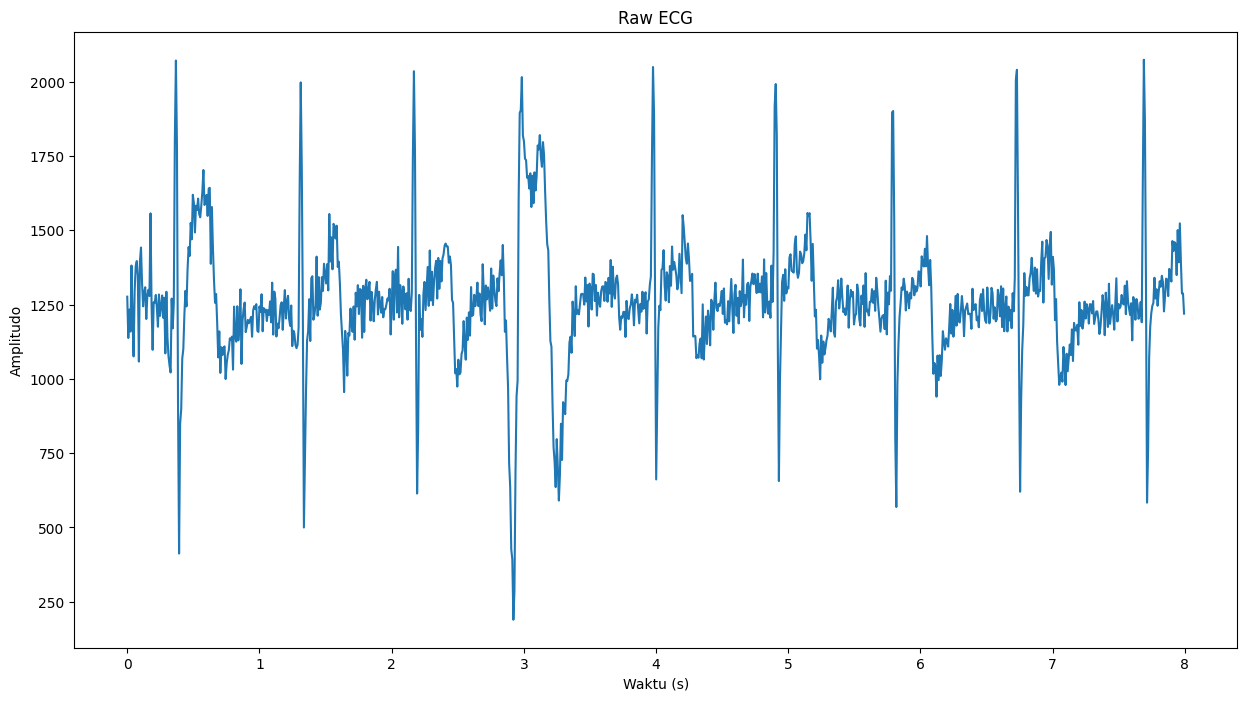

In [27]:
plt.figure(figsize=(15,8))
plt.plot(time_resample[:1000], ecg_resample[:1000])
plt.title("Raw ECG")
plt.ylabel("Amplitudo")
plt.xlabel("Waktu (s)")
plt.show()

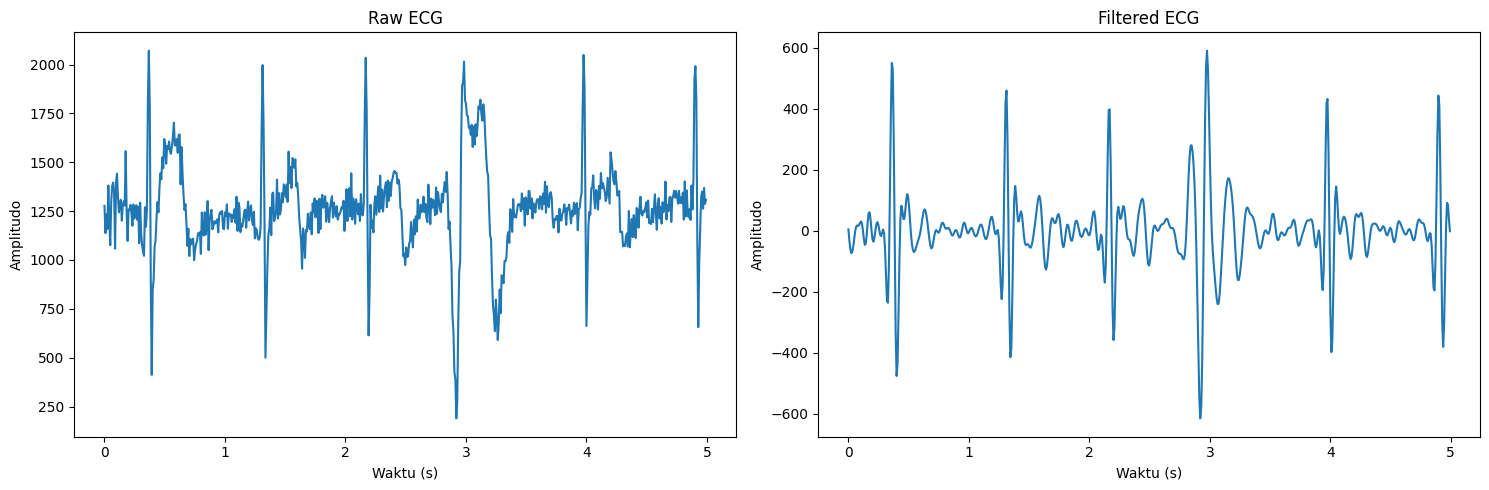

In [28]:
# pre-processing
# bandpass filter 5 - 18 Hz untuk menghilangkan noise ecg

def bandpass(x, low_cut, high_cut, fs = 125, order=4):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, x)
    return filtered_signal

ecg_bpf = bandpass(ecg_resample, 5, 18)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
durasi = time_resample <= 5

ax[0].plot(time_resample[durasi], ecg_resample[durasi])
ax[0].set_title("Raw ECG")
ax[0].set_ylabel("Amplitudo")
ax[0].set_xlabel("Waktu (s)")

ax[1].plot(time_resample[durasi], ecg_bpf[durasi])
ax[1].set_title("Filtered ECG")
ax[1].set_ylabel("Amplitudo")
ax[1].set_xlabel("Waktu (s)")

plt.tight_layout()
plt.show()

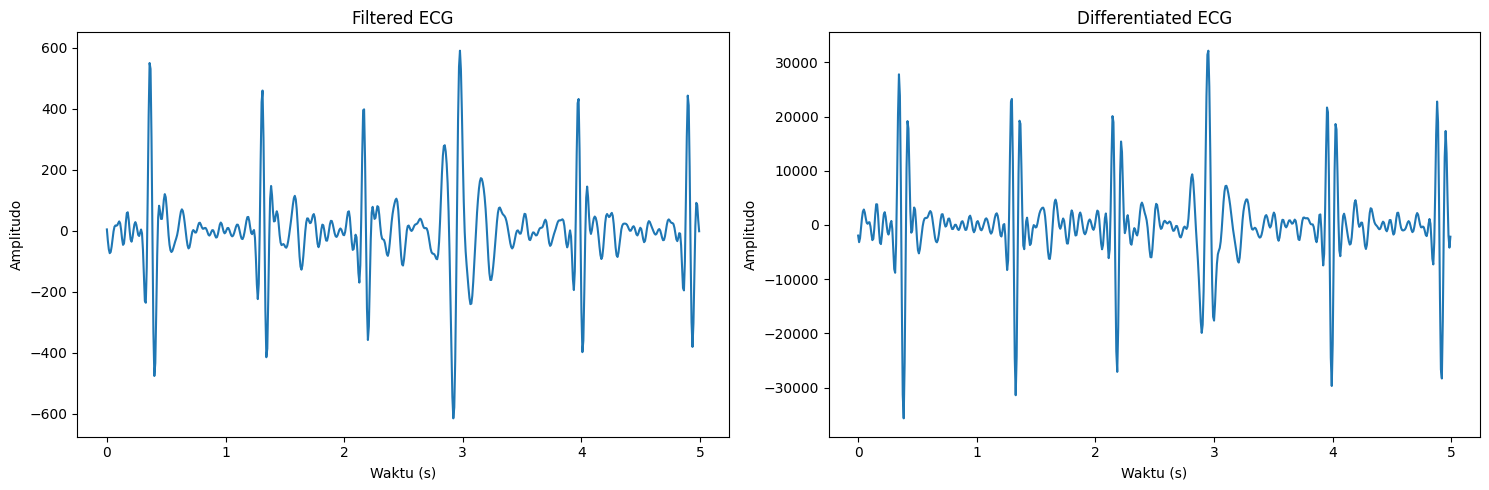

In [29]:
# differensiasi sinyal ecg
T = 1/target_fs
kernel = np.array([1, 2, 0, -2, -1]) * (1.0 / (8 * T)) # rumus differensiasi sinyal
ecg_diff = np.convolve(ecg_bpf, kernel, mode='same')

fig,ax=plt.subplots(1,2,figsize=(15,5))

ax[0].plot(time_resample[durasi], ecg_bpf[durasi])
ax[0].set_title("Filtered ECG")
ax[0].set_ylabel("Amplitudo")
ax[0].set_xlabel("Waktu (s)")

ax[1].plot(time_resample[durasi], ecg_diff[durasi])
ax[1].set_title("Differentiated ECG")
ax[1].set_ylabel("Amplitudo")
ax[1].set_xlabel("Waktu (s)")

plt.tight_layout()
plt.show()

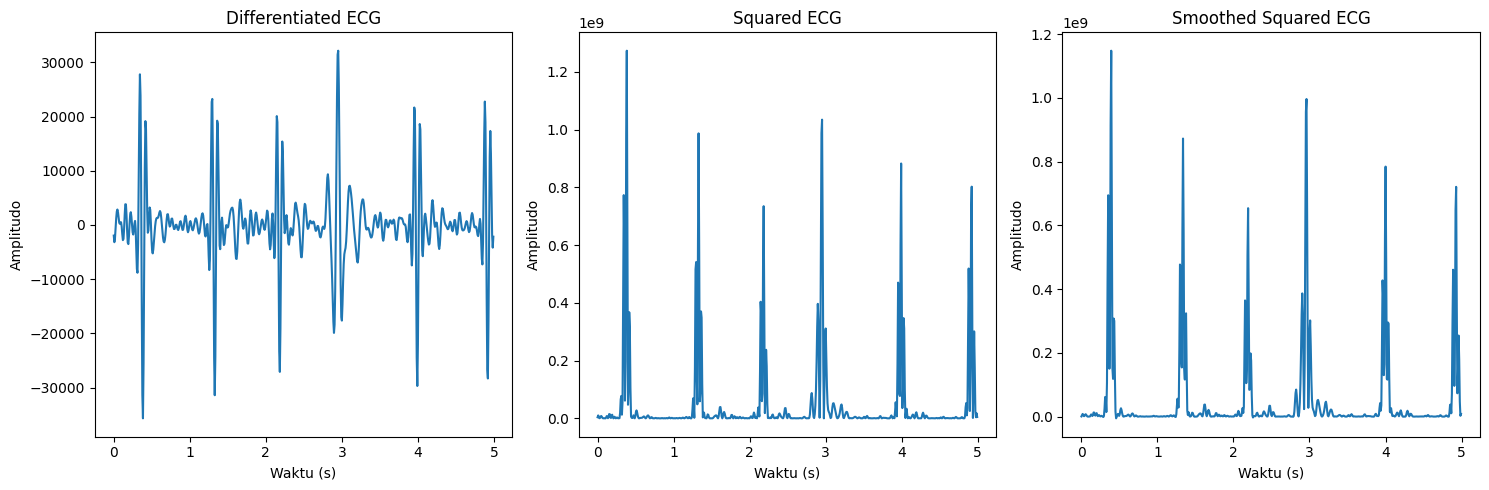

In [30]:
# square sinyal ecg
ecg_squared = ecg_diff * ecg_diff

# smoothing
window_duration_smooth = 0.060  # 60 ms dari paper
N_smooth = int(np.round(window_duration_smooth * target_fs))

n = np.arange(N_smooth)
psi = (2 * np.pi * n) / N_smooth
a0, a1, a2, a3, a4 = (
    0.2155789,
    0.4166316,
    0.27726316,
    0.08357895,
    0.00694737,
) # nilainya dapet dari paper

flattop_win = (
    a0
    - a1 * np.cos(psi)
    + a2 * np.cos(2 * psi)
    - a3 * np.cos(3 * psi)
    + a4 * np.cos(4 * psi)
)

# normalisasi
flattop_win = flattop_win / np.sum(flattop_win)
ecg_smoothed = np.convolve(ecg_squared, flattop_win, mode="same")

fig, ax = plt.subplots(1,3,figsize=(15,5))

ax[0].plot(time_resample[durasi], ecg_diff[durasi])
ax[0].set_title("Differentiated ECG")
ax[0].set_ylabel("Amplitudo")
ax[0].set_xlabel("Waktu (s)")

ax[1].plot(time_resample[durasi], ecg_squared[durasi])
ax[1].set_title("Squared ECG")
ax[1].set_ylabel("Amplitudo")
ax[1].set_xlabel("Waktu (s)")

ax[2].plot(time_resample[durasi], ecg_smoothed[durasi])
ax[2].set_title("Smoothed Squared ECG")
ax[2].set_ylabel("Amplitudo")
ax[2].set_xlabel("Waktu (s)")

plt.tight_layout()
plt.show()


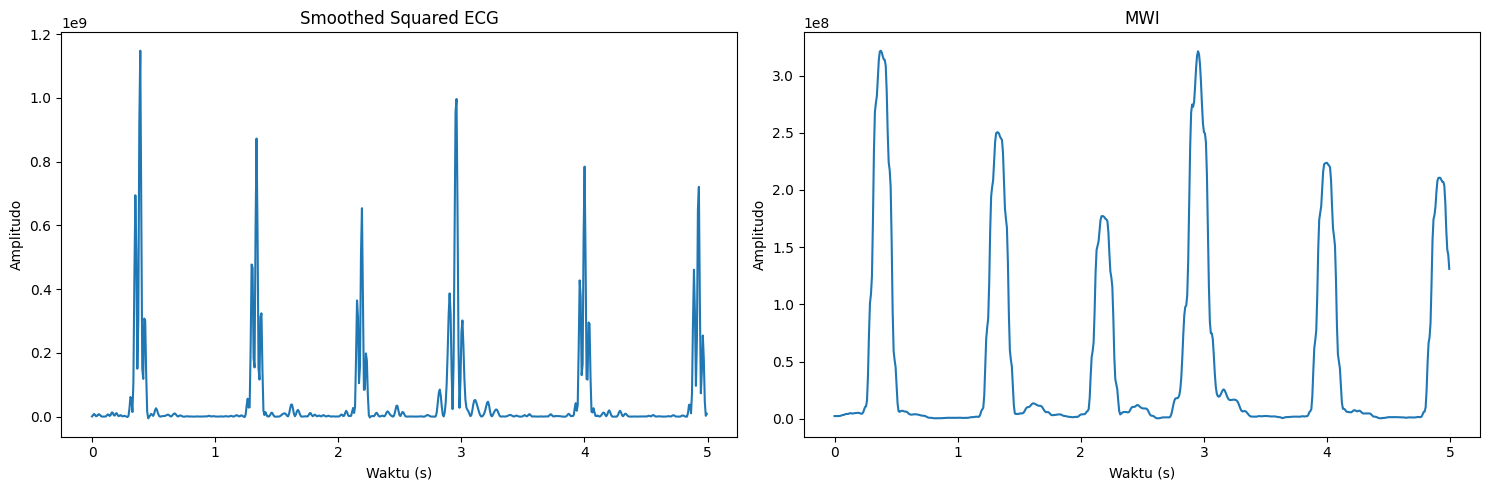

In [31]:
# Moving Window Integration (MWI) mirip MAV
window_duration_mwi = 0.150  # 150 ms dari paper
N_mwi = int(np.round(window_duration_mwi * target_fs))

kernel_mwi = np.ones(N_mwi) / N_mwi
ecg_mwi = np.convolve(ecg_smoothed, kernel_mwi, mode="same")

fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(time_resample[durasi], ecg_smoothed[durasi])
ax[0].set_title("Smoothed Squared ECG")
ax[0].set_ylabel("Amplitudo")
ax[0].set_xlabel("Waktu (s)")

ax[1].plot(time_resample[durasi], ecg_mwi[durasi])
ax[1].set_title("MWI")
ax[1].set_ylabel("Amplitudo")
ax[1].set_xlabel("Waktu (s)")

plt.tight_layout()
plt.show()

Jumlah kandidat puncak terdeteksi (SciPy): 184 puncak


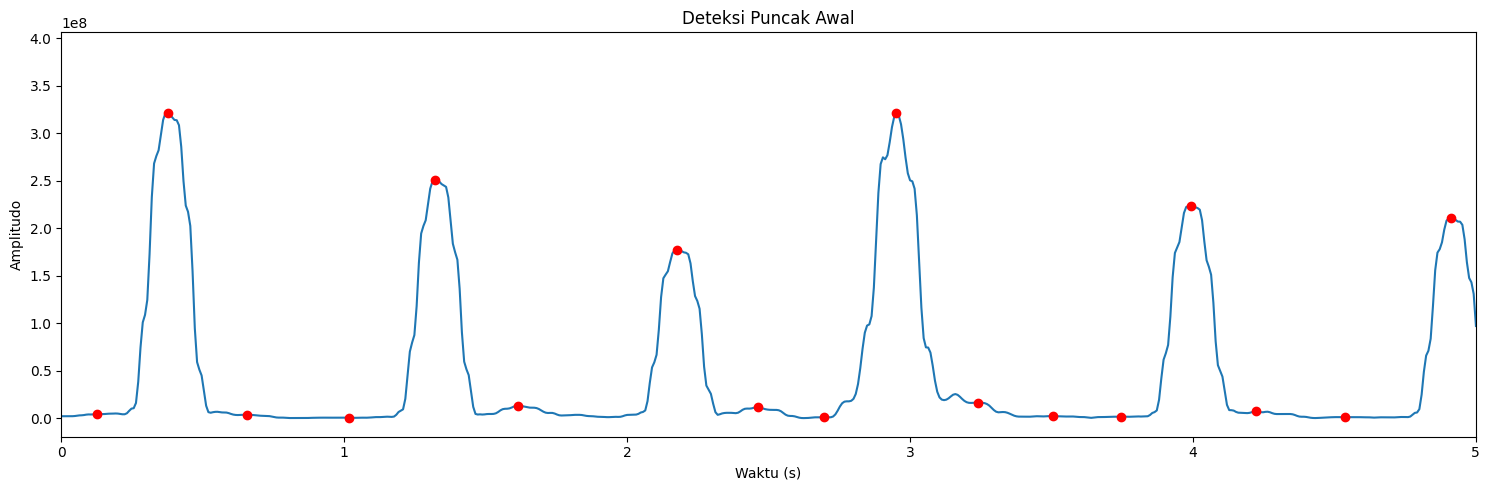

In [32]:
# penentuan peak to peak 1
# Perhitungan jarak minimum sampel (Refractory period 231 ms)
refractory_period_sec = 0.231
min_distance_samples = int(np.round(refractory_period_sec * target_fs))

# Deteksi kandidat puncak awal dengan scipy
peak_indices_scipy, _ = find_peaks(ecg_mwi, distance=min_distance_samples)
print(f"Jumlah kandidat puncak terdeteksi (SciPy): {len(peak_indices_scipy)} puncak")
t_start = 0
t_end = 5

plt.figure(figsize=(15, 5))
plt.plot(time_resample, ecg_mwi, label="Sinyal MWI", color="tab:blue", lw=1.5)
plt.plot(time_resample[peak_indices_scipy],ecg_mwi[peak_indices_scipy],"ro",)
plt.xlim([t_start, t_end])
plt.title(f"Deteksi Puncak Awal")
plt.xlabel("Waktu (s)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()


In [33]:
def custom_find_peaks(signal, distance):
    # 1. Cari seluruh lokal maksima pada sinyal
    local_peaks = []
    for i in range(1, len(signal) - 1):
        if signal[i] > signal[i - 1] and signal[i] > signal[i + 1]:
            local_peaks.append(i)

    if not local_peaks:
        return np.array([])

    # 2. Urutkan kandidat puncak berdasarkan amplitudonya (dari tertinggi ke terendah)
    #    agar puncak yang lebih tinggi diprioritaskan saat penyaringan jarak
    sorted_candidates = sorted(
        local_peaks, key=lambda idx: signal[idx], reverse=True
    )

    selected_peaks = []
    for candidate in sorted_candidates:
        # Periksa apakah kandidat ini berjarak minimal 'distance' dari puncak yang sudah terpilih
        is_valid = True
        for prev_peak in selected_peaks:
            if abs(candidate - prev_peak) < distance:
                is_valid = False
                break

        if is_valid:
            selected_peaks.append(candidate)

    # 3. Urutkan kembali indeks puncak berdasarkan posisi waktu (kronologis)
    return np.array(sorted(selected_peaks))


# Perhitungan jarak minimum sampel
min_distance_samples = int(np.round(0.231 * target_fs))

# Deteksi kandidat puncak awal secara manual
peak_indices_custom = custom_find_peaks(ecg_mwi, distance=min_distance_samples)

print(
    f"Jumlah kandidat puncak terdeteksi (Custom): {len(peak_indices_custom)} puncak"
)

Jumlah kandidat puncak terdeteksi (Custom): 184 puncak


In [34]:
# 1. Tentukan jumlah sampel untuk 2 detik pertama sinyal
init_duration_sec = 2.0
init_samples = int(np.round(init_duration_sec * target_fs))

# Ambil cuplikan sinyal MWI pada 2 detik pertama
mwi_2sec = ecg_mwi[:init_samples]

# 2. Hitung nilai statistik MAXF dan MEANF
MAXF = np.max(mwi_2sec)
MEANF = np.mean(mwi_2sec)

# 3. Hitung ambang batas awal (Threshold1 & Threshold2)
Threshold1 = MAXF / 3.0
Threshold2 = 0.5 * MEANF

# 4. Inisialisasi variabel estimasi running SPK dan NPK
SPK = Threshold1
NPK = Threshold2

# Menampilkan hasil inisialisasi
print("--- Hasil Inisialisasi Threshold (2 Detik Pertama) ---")
print(f"MAXF (Amplitudo Maksimum)  : {MAXF:.6f}")
print(f"MEANF (Rata-rata Amplitudo): {MEANF:.6f}")
print(f"Threshold1 (Awal)          : {Threshold1:.6f}")
print(f"Threshold2 (Awal)          : {Threshold2:.6f}")
print(f"SPK (Signal Peak)          : {SPK:.6f}")
print(f"NPK (Noise Peak)           : {NPK:.6f}")

--- Hasil Inisialisasi Threshold (2 Detik Pertama) ---
MAXF (Amplitudo Maksimum)  : 321690025.343646
MEANF (Rata-rata Amplitudo): 46642111.378912
Threshold1 (Awal)          : 107230008.447882
Threshold2 (Awal)          : 23321055.689456
SPK (Signal Peak)          : 107230008.447882
NPK (Noise Peak)           : 23321055.689456


In [35]:
# Array/List untuk menyimpan hasil pengelompokan puncak
r_peaks = []
noise_peaks = []

# Gunakan variabel running dari hasil inisialisasi
spk = SPK
npk = NPK
th1 = Threshold1
th2 = Threshold2

# Iterasi pada setiap kandidat puncak awal (dari scipy / custom)
for peak_idx in peak_indices_scipy:
    peak_val = ecg_mwi[peak_idx]

    # Evaluasi terhadap Threshold1 utama
    if peak_val > th1:
        # 1. Klasifikasikan sebagai R-peak
        r_peaks.append(peak_idx)

        # 2. Perbarui SPK menggunakan Rule-1
        spk = 0.125 * peak_val + 0.875 * spk
    else:
        # 1. Klasifikasikan sebagai Noise Peak
        noise_peaks.append(peak_idx)

        # 2. Perbarui NPK menggunakan Rule-1
        npk = 0.125 * peak_val + 0.875 * npk

    # 3. Perbarui Ambang Batas secara Dinamis (Aturan Pan-Tompkins++)
    th1 = npk + 0.25 * (spk - npk)
    th2 = 0.4 * th1

print(f"Total R-peaks sementara (Normal Check): {len(r_peaks)}")
print(f"Total Noise peaks sementara            : {len(noise_peaks)}")

Total R-peaks sementara (Normal Check): 63
Total Noise peaks sementara            : 121


In [36]:
# Hitung jumlah sampel untuk jendela 70 ms
N_70 = int(np.round(0.070 * target_fs))


def calculate_mean_slope(signal, peak_idx, window_samples):
    """Menghitung rata-rata kemiringan (mean slope) 70 ms sebelum posisi peak_idx."""
    start_idx = max(0, peak_idx - window_samples)
    segment = signal[start_idx : peak_idx + 1]

    if len(segment) < 2:
        return 0.0

    # Kemiringan dihitung dari selisih absolut antar sampel berurutan
    slope = np.mean(np.abs(np.diff(segment)))
    return slope

r_peaks = []
noise_peaks = []

for peak_idx in peak_indices_scipy:
    peak_val = ecg_mwi[peak_idx]

    if peak_val > th1:
        is_r_peak = True

        # Periksa apakah sudah ada minimal 1 R-peak yang terdeteksi sebelumnya
        if len(r_peaks) > 0:
            last_r_idx = r_peaks[-1]
            current_rr_samples = peak_idx - last_r_idx
            current_rr_sec = current_rr_samples / target_fs

            # Hitung Mean RR-interval dari maksimal 8 detak terakhir
            if len(r_peaks) >= 2:
                recent_r = r_peaks[-8:]
                rr_intervals = np.diff(recent_r) / target_fs
                mean_rr_sec = np.mean(rr_intervals)
            else:
                mean_rr_sec = current_rr_sec

            # Syarat pengujian Gelombang T
            if current_rr_sec < 0.360 or current_rr_sec < (0.5 * mean_rr_sec):
                # Hitung slope 70 ms kandidat puncak & R-peak sebelumnya
                slope_curr = calculate_mean_slope(ecg_mwi, peak_idx, N_70)
                slope_prev = calculate_mean_slope(ecg_mwi, last_r_idx, N_70)

                # Kriteria Gelombang T: slope kurang dari 60% slope QRS sebelumnya
                if slope_curr < 0.60 * slope_prev:
                    is_r_peak = False  # Diklasifikasikan sebagai T-Wave/Noise

        if is_r_peak:
            r_peaks.append(peak_idx)
            spk = 0.125 * peak_val + 0.875 * spk
        else:
            noise_peaks.append(peak_idx)
            npk = 0.125 * peak_val + 0.875 * npk
    else:
        noise_peaks.append(peak_idx)
        npk = 0.125 * peak_val + 0.875 * npk

    # Pembaruan threshold dinamis
    th1 = npk + 0.25 * (spk - npk)
    th2 = 0.4 * th1

print(f"Total R-peaks sementara (Normal Check): {len(r_peaks)}")
print(f"Total Noise peaks            : {len(noise_peaks)}")

Total R-peaks sementara (Normal Check): 63
Total Noise peaks            : 121


In [37]:
def calculate_meansb(r_peaks, all_peaks, current_peak_idx, signal):
    """Menghitung MEANSB: Rata-rata amplitudo dari 3 QRS sebelumnya dan 3 puncak setelahnya."""
    # 1. Ambil amplitudo 3 QRS terakhir
    prev_qrs_vals = [signal[idx] for idx in r_peaks[-3:]] if r_peaks else []

    # 2. Cari indeks puncak setelah kandidat saat ini
    future_peaks = [idx for idx in all_peaks if idx > current_peak_idx]
    next_peak_vals = [signal[idx] for idx in future_peaks[:3]]

    # 3. Gabungkan seluruh sampel yang tersedia
    combined_vals = prev_qrs_vals + [signal[current_peak_idx]] + next_peak_vals

    return np.mean(combined_vals) if combined_vals else signal[current_peak_idx]

r_peaks = []
noise_peaks = []

for peak_idx in peak_indices_scipy:
    peak_val = ecg_mwi[peak_idx]

    # Hitung RR-interval dan Mean RR-interval (dari 8 detak terakhir)
    if len(r_peaks) > 0:
        last_r_idx = r_peaks[-1]
        current_rr_sec = (peak_idx - last_r_idx) / target_fs

        if len(r_peaks) >= 2:
            recent_r = r_peaks[-8:]
            mean_rr_sec = np.mean(np.diff(recent_r) / target_fs)
        else:
            mean_rr_sec = current_rr_sec
    else:
        current_rr_sec = 0.0
        mean_rr_sec = 0.0

    is_classified = False

    # -------------------------------------------------------------------------
    # UJI 1: Pendeteksian R-Peak Normal & Eliminasi Gelombang T
    # -------------------------------------------------------------------------
    if peak_val > th1:
        is_r_peak = True

        # Evaluasi Gelombang T ( False Positive Check )
        if len(r_peaks) > 0 and (
            current_rr_sec < 0.360 or current_rr_sec < (0.5 * mean_rr_sec)
        ):
            slope_curr = calculate_mean_slope(ecg_mwi, peak_idx, N_70)
            slope_prev = calculate_mean_slope(ecg_mwi, last_r_idx, N_70)

            if slope_curr < 0.60 * slope_prev:
                is_r_peak = False  # Diklasifikasikan sebagai T-Wave/Noise

        if is_r_peak:
            r_peaks.append(peak_idx)
            spk = 0.125 * peak_val + 0.875 * spk  # Rule-1
            is_classified = True
        else:
            noise_peaks.append(peak_idx)
            npk = 0.125 * peak_val + 0.875 * npk  # Rule-1
            is_classified = True

    # -------------------------------------------------------------------------
    # UJI 2 (Langkah 5): Search-Back Mechanism (Puncak Hilang)
    # -------------------------------------------------------------------------
    elif len(r_peaks) > 0 and (
        current_rr_sec > 1.0 or current_rr_sec > (1.66 * mean_rr_sec)
    ):
        meansb = calculate_meansb(
            r_peaks, peak_indices_scipy, peak_idx, ecg_mwi
        )
        th3 = 0.5 * th2 + 0.5 * meansb

        if peak_val > th3:
            r_peaks.append(peak_idx)
            spk = 0.75 * peak_val + 0.25 * spk  # Rule-2
            npk = 0.75 * peak_val + 0.25 * npk  # Rule-2
            is_classified = True

    # -------------------------------------------------------------------------
    # UJI 3 (Langkah 6): Recovery dari Extreme High R-Peaks (RR > 1.4s)
    # -------------------------------------------------------------------------
    if not is_classified and len(r_peaks) > 0 and current_rr_sec > 1.4:
        if peak_val > (0.2 * th2):
            r_peaks.append(peak_idx)
            spk = 0.75 * peak_val + 0.25 * spk  # Rule-2
            npk = 0.75 * peak_val + 0.25 * npk  # Rule-2
            is_classified = True

    # -------------------------------------------------------------------------
    # CABANG TERAKHIR: Jika tidak lolos semua kriteria di atas -> Noise Peak
    # -------------------------------------------------------------------------
    if not is_classified:
        noise_peaks.append(peak_idx)
        npk = 0.125 * peak_val + 0.875 * npk  # Rule-1

    # -------------------------------------------------------------------------
    # Langkah 7: Pembaruan Ambang Batas Keseluruhan secara Dinamis
    # -------------------------------------------------------------------------
    th1 = npk + 0.25 * (spk - npk)
    th2 = 0.4 * th1  # Pengali 0.4 khas Pan-Tompkins++

# Output Ringkasan Hasil
print("=== HASIL AKHIR DETEKSI PAN-TOMPKINS++ ===")
print(f"Total R-Peaks Terdeteksi : {len(r_peaks)}")
print(f"Total Noise Peaks        : {len(noise_peaks)}")

=== HASIL AKHIR DETEKSI PAN-TOMPKINS++ ===
Total R-Peaks Terdeteksi : 63
Total Noise Peaks        : 121


In [38]:
durasi_menit = time_resample[-1] / 60.0
bpm_overall = len(r_peaks) / durasi_menit

# -----------------------------------------------------------------------------
# METODE 2: Mean RR-Interval HR (Metode Standar Klinis)
# -----------------------------------------------------------------------------
if len(r_peaks) > 1:
    # 1. Hitung selisih sampel antar R-peak berurutan
    rr_samples = np.diff(r_peaks)

    # 2. Konversi selisih sampel ke satuan detik
    rr_intervals_sec = rr_samples / target_fs

    # 3. Hitung rata-rata interval RR (detik)
    mean_rr_sec = np.mean(rr_intervals_sec)

    # 4. Hitung BPM standar
    bpm_rr = 60.0 / mean_rr_sec

    # (Bonus) Statistik Detak Jantung Instan & Variabilitas (HRV sederhana)
    bpm_instantaneous = 60.0 / rr_intervals_sec
    min_bpm = np.min(bpm_instantaneous)
    max_bpm = np.max(bpm_instantaneous)
    sdnn_ms = (
        np.std(rr_intervals_sec) * 1000.0
    )  # Standard Deviation of NN/RR intervals (ms)

    # -----------------------------------------------------------------------------
    # Output Hasil
    # -----------------------------------------------------------------------------
    print("=== HASIL PERHITUNGAN HEART RATE (BPM) ===")
    print(f"Total R-Peaks Terdeteksi   : {len(r_peaks)}")
    print(f"1. HR Rata-Rata Keseluruhan : {bpm_overall:.2f} BPM")
    print(f"2. HR Standar (Interval RR) : {bpm_rr:.2f} BPM")
    print(f"   - Rata-rata Interval RR : {mean_rr_sec * 1000:.2f} ms")
    print(f"   - Rentang HR Instan     : {min_bpm:.2f} - {max_bpm:.2f} BPM")
    print(f"   - Variabilitas (SDNN)   : {sdnn_ms:.2f} ms")
else:
    print("Jumlah R-peak tidak cukup untuk menghitung interval RR.")

=== HASIL PERHITUNGAN HEART RATE (BPM) ===
Total R-Peaks Terdeteksi   : 63
1. HR Rata-Rata Keseluruhan : 63.00 BPM
2. HR Standar (Interval RR) : 63.43 BPM
   - Rata-rata Interval RR : 945.94 ms
   - Rentang HR Instan     : 46.58 - 88.24 BPM
   - Variabilitas (SDNN)   : 115.59 ms


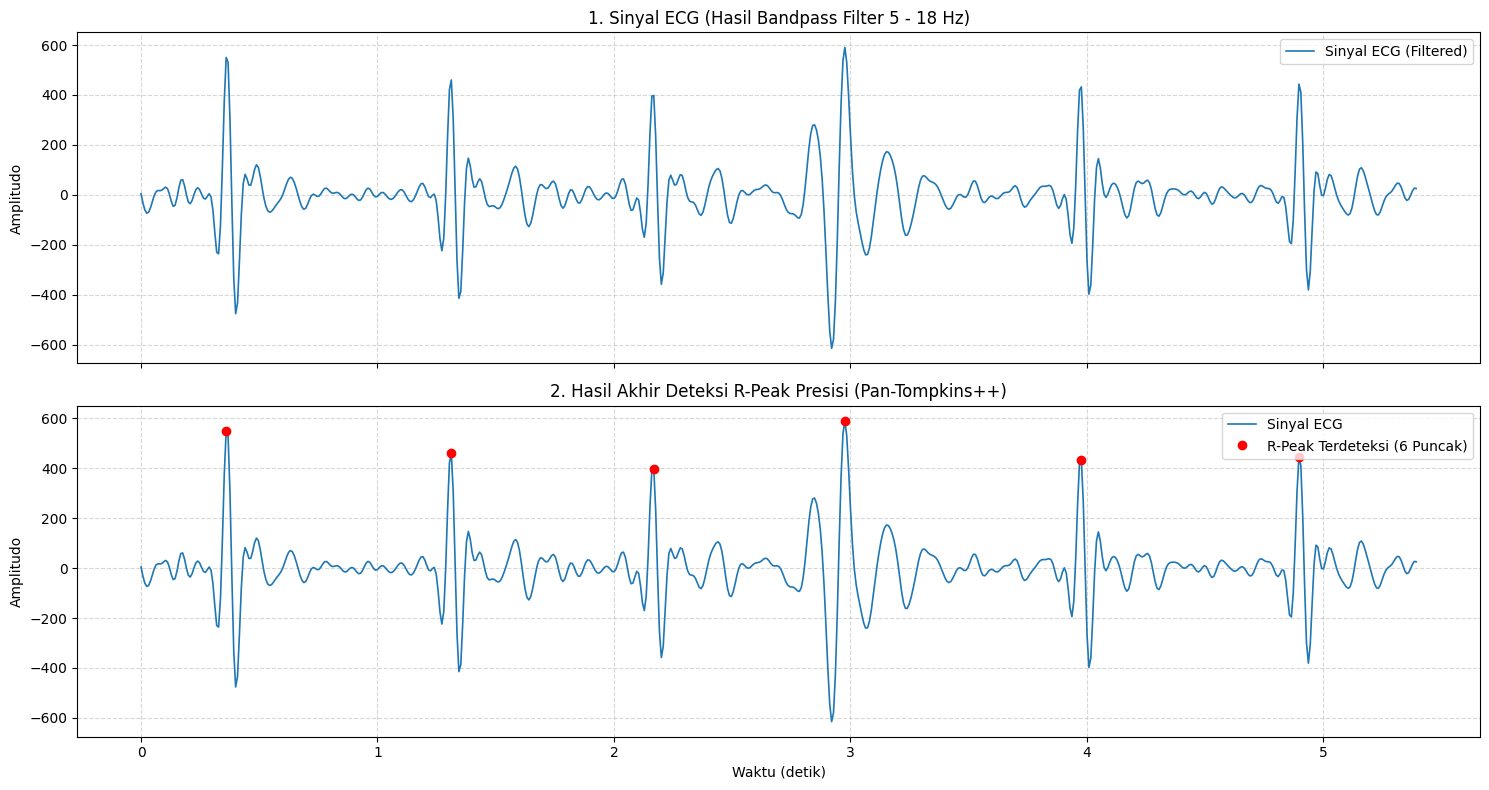

In [39]:
start_idx = 0
end_idx = 675
def align_r_peaks_to_ecg(
    r_peaks_mwi, ecg_signal, fs, search_window_ms=150
):
    """Mencari puncak tertinggi pada sinyal ecg_bpf di sekitar (mundur)

    indeks puncak MWI untuk mengoreksi delay filter.
    """
    aligned_peaks = []
    # Konversi jendela pencarian (150 ms) ke jumlah sampel
    search_samples = int(np.round((search_window_ms / 1000.0) * fs))

    for p in r_peaks_mwi:
        # Karena MWI menyebabkan delay (pergeseran ke kanan),
        # R-peak asli di ecg_bpf berada di sebelah kiri dari p
        start_idx = max(0, p - search_samples)
        end_idx = min(len(ecg_signal), p + 10)  # Toleransi sedikit ke kanan

        # Cari indeks dengan amplitudo tertinggi pada segmen ecg_bpf
        local_max_idx = start_idx + np.argmax(ecg_signal[start_idx:end_idx])
        aligned_peaks.append(local_max_idx)

    return np.array(aligned_peaks)


# Koreksi posisi R-peaks agar presisi di puncak ecg_bpf
r_peaks_aligned = align_r_peaks_to_ecg(r_peaks, ecg_bpf, target_fs)
# Filter R-peaks yang sudah ter-align sesuai rentang tampilan
r_peaks_in_range_aligned = [
    p for p in r_peaks_aligned if start_idx <= p < end_idx
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Subplot 1: Sinyal Filtered
ax1.plot(
    time_resample[start_idx:end_idx],
    ecg_bpf[start_idx:end_idx],
    color="tab:blue",
    linewidth=1.2,
    label="Sinyal ECG (Filtered)",
)
ax1.set_title("1. Sinyal ECG (Hasil Bandpass Filter 5 - 18 Hz)", fontsize=12)
ax1.set_ylabel("Amplitudo", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right")

# Subplot 2: Hasil Akhir Deteksi Presisi (Tepat di Puncak)
ax2.plot(
    time_resample[start_idx:end_idx],
    ecg_bpf[start_idx:end_idx],
    color="tab:blue",
    linewidth=1.2,
    label="Sinyal ECG",
)
ax2.plot(
    time_resample[r_peaks_in_range_aligned],
    ecg_bpf[r_peaks_in_range_aligned],
    "ro",
    markersize=6,
    label=f"R-Peak Terdeteksi ({len(r_peaks_in_range_aligned)} Puncak)",
)
ax2.set_title(
    "2. Hasil Akhir Deteksi R-Peak Presisi (Pan-Tompkins++)", fontsize=12
)
ax2.set_xlabel("Waktu (detik)", fontsize=10)
ax2.set_ylabel("Amplitudo", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [40]:
import numpy as np
from scipy.ndimage import median_filter
from scipy.signal import butter, filtfilt, iirnotch, savgol_filter


def build_clinical_diagnostic_filter_chain_v2(
    ecg_raw,
    fs,
    lp_cutoff=25.0,  # Diturunkan ke 25 Hz untuk meredam noise P & T
    sg_window=11,  # Dinaikkan ke 11 sampel (~88 ms) agar lebih smooth
    polyorder=2,
    abs_threshold=500.0,
    artifact_sensitivity=2.5,
):
    """Membangun Clinical-Grade Diagnostic Filter Chain v2 (Extra Smooth for P & T Waves).

    - Baseline Wander : Double Median Filter (200 ms & 600 ms)
    - Low-Pass Filter : 25 Hz (Monitor Display Standard)
    - Notch Filter    : 50 Hz
    - Smoothing       : Savitzky-Golay (Window 11 (~88ms), Poly 2)
    - Artifact Mask   : Absolute Threshold + Local Moving STD
    """
    # =========================================================================
    # 1. BASELINE WANDER REMOVAL: Double Median Filter (200 ms & 600 ms)
    # =========================================================================
    w1 = int(np.round(0.200 * fs))
    if w1 % 2 == 0:
        w1 += 1
    w2 = int(np.round(0.600 * fs))
    if w2 % 2 == 0:
        w2 += 1

    baseline_step1 = median_filter(ecg_raw, size=w1)
    baseline_trend = median_filter(baseline_step1, size=w2)
    ecg_detrend = ecg_raw - baseline_trend

    # =========================================================================
    # 2. NOISE FILTERING: Low-Pass (25 Hz) & Notch (50 Hz)
    # =========================================================================
    # Low-pass Butterworth 25 Hz (Membersihkan riak pada P dan T wave)
    b_lp, a_lp = butter(N=3, Wn=lp_cutoff, btype="lowpass", fs=fs)
    ecg_lp = filtfilt(b_lp, a_lp, ecg_detrend)

    # Notch Filter 50 Hz
    if 50.0 < (fs / 2.0):
        b_notch, a_notch = iirnotch(w0=50.0, Q=30.0, fs=fs)
        ecg_notch = filtfilt(b_notch, a_notch, ecg_lp)
    else:
        ecg_notch = ecg_lp

    # =========================================================================
    # 3. SMOOTHING: Savitzky-Golay Filter (Ukuran Jendela 11)
    # =========================================================================
    if sg_window % 2 == 0:
        sg_window += 1

    ecg_smooth = savgol_filter(
        ecg_notch, window_length=sg_window, polyorder=polyorder
    )

    # =========================================================================
    # 4. ARTIFACT REJECTION (Threshold Absolut + Moving STD)
    # =========================================================================
    mask_amplitude = np.abs(ecg_smooth) > abs_threshold

    win_1s = int(np.round(1.0 * fs))
    padded_signal = np.pad(
        ecg_smooth, (win_1s // 2, win_1s // 2), mode="reflect"
    )
    local_std = np.array(
        [np.std(padded_signal[i : i + win_1s]) for i in range(len(ecg_smooth))]
    )

    valid_std = local_std[~mask_amplitude]
    median_std = (
        np.median(valid_std) if len(valid_std) > 0 else np.median(local_std)
    )

    mask_variance = local_std > (artifact_sensitivity * median_std)
    artifact_mask = mask_amplitude | mask_variance

    ecg_clinical = ecg_smooth.copy()
    ecg_clinical[artifact_mask] = np.nan

    return ecg_clinical, artifact_mask, ecg_smooth


# =============================================================================
# EKSEKUSI FUNGSI BARU
# =============================================================================
ecg_clinical, artifact_mask, ecg_smooth = (
    build_clinical_diagnostic_filter_chain_v2(
        ecg_resample,
        target_fs,
        lp_cutoff=25.0,  # Menggunakan 25 Hz agar P & T mulus
        sg_window=11,  # Jendela 11 (~88ms)
        polyorder=2,
    )
)

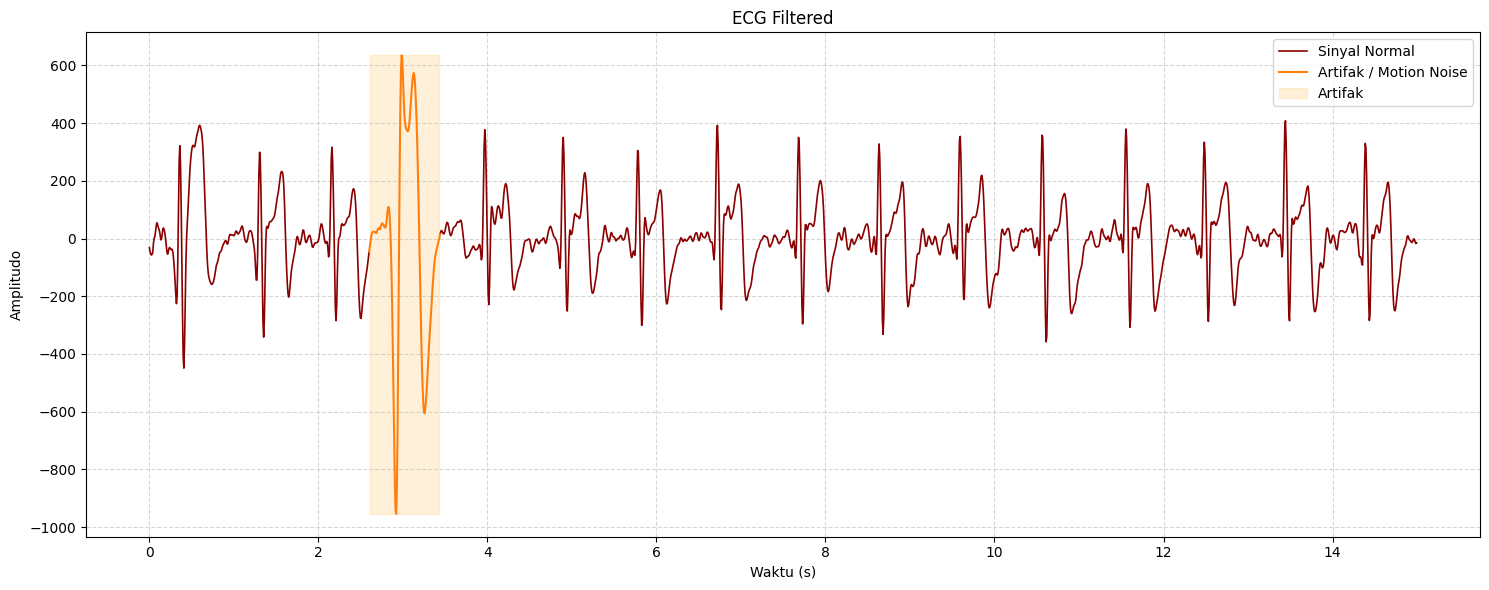

In [41]:
from scipy.ndimage import binary_dilation
# Perluas mask artifak sebanyak 1 sampel ke kanan & kiri agar sambungan garis menyatu
mask_corrupted_dilated = binary_dilation(artifact_mask, iterations=1)

# A. Array Sinyal Bersih (Area Artifak di-set np.nan)
ecg_clean_display = np.where(~artifact_mask, ecg_smooth, np.nan)

# B. Array Sinyal Artifak (Area Bersih di-set np.nan, menggunakan mask ter-dilatasi)
ecg_corrupted_display = np.where(mask_corrupted_dilated, ecg_smooth, np.nan)


# =============================================================================
# 2. PLOTTING VISUALISASI DUA WARNA
# =============================================================================
# Tentukan rentang waktu tampilan (misal: 0 sampai 60 detik)
t_start = 0
t_end = 15

start_idx = int(t_start * target_fs)
end_idx = int(t_end * target_fs)

time_win = time_resample[start_idx:end_idx]
clean_win = ecg_clean_display[start_idx:end_idx]
corrupted_win = ecg_corrupted_display[start_idx:end_idx]
mask_win = artifact_mask[start_idx:end_idx]

plt.figure(figsize=(15, 6))

# 1. Plot Sinyal Normal/Bersih (Warna Merah Tua / Dark Red)
plt.plot(
    time_win,
    clean_win,
    color="darkred",
    linewidth=1.2,
    label="Sinyal Normal",
)

# 2. Plot Sinyal Terkontaminasi Artifak (Warna Oranye Terang / Bright Orange)
plt.plot(
    time_win,
    corrupted_win,
    color="tab:orange",
    linewidth=1.5,
    linestyle="-",
    label="Artifak / Motion Noise",
)

# 3. (Opsional) Tambahkan highlight latar belakang tipis di area artifak
plt.fill_between(
    time_win,
    np.nanmin(ecg_smooth[start_idx:end_idx]),
    np.nanmax(ecg_smooth[start_idx:end_idx]),
    where=mask_win,
    color="orange",
    alpha=0.15,
    label="Artifak",
)

plt.title(
    "ECG Filtered",
    fontsize=12,
)
plt.xlabel("Waktu (s)", fontsize=10)
plt.ylabel("Amplitudo", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [42]:
import numpy as np


def calculate_snr_residual(ecg_raw, ecg_filtered):
    """Menghitung SNR berdasarkan estimasi residual noise dari proses filtering.

    - ecg_raw      : Sinyal mentah (ecg_resample)
    - ecg_filtered : Sinyal bersih hasil filter chain (ecg_smooth)
    """
    # 1. Hitung komponen noise (residual)
    noise = ecg_raw - ecg_filtered

    # 2. Hitung daya (power / variance) sinyal dan noise
    power_signal = np.mean(ecg_filtered**2)
    power_noise = np.mean(noise**2)

    # Mencegah pembagian dengan nol
    if power_noise == 0:
        return float("inf")

    # 3. Hitung SNR dalam desibel (dB)
    snr_db = 10 * np.log10(power_signal / power_noise)
    return snr_db


# Contoh Eksekusi:
snr_residual = calculate_snr_residual(
    ecg_raw=ecg_resample, ecg_filtered=ecg_smooth
)
print(f"1. SNR Metode Residual Filter : {snr_residual:.2f} dB")

1. SNR Metode Residual Filter : -17.97 dB


In [43]:
def calculate_snr_isoelectric(ecg_signal, r_peaks, fs):
    """Menghitung SNR berbasis rasio daya QRS terhadap garis dasar isoelektrik (TP segment).

    - ecg_signal : Sinyal ECG yang dievaluasi (ecg_smooth atau ecg_resample)
    - r_peaks    : Indeks R-peaks terdeteksi (r_peaks_aligned)
    - fs         : Frekuensi sampling (Hz)
    """
    # Jendela sampel
    qrs_half_win = int(np.round(0.060 * fs))  # ±60 ms di sekitar R-peak (QRS)
    tp_start = int(np.round(0.250 * fs))  # +250 ms setelah R-peak (awal TP)
    tp_end = int(np.round(0.450 * fs))  # +450 ms setelah R-peak (akhir TP)

    qrs_powers = []
    tp_powers = []

    for r in r_peaks:
        # Pastikan indeks berada di dalam batas array sinyal
        if (r - qrs_half_win >= 0) and (r + tp_end < len(ecg_signal)):
            # Segmen QRS
            qrs_seg = ecg_signal[r - qrs_half_win : r + qrs_half_win]
            qrs_powers.append(np.var(qrs_seg))

            # Segmen TP (Isoelektrik / Noise)
            tp_seg = ecg_signal[r + tp_start : r + tp_end]
            tp_powers.append(np.var(tp_seg))

    if len(qrs_powers) == 0 or len(tp_powers) == 0:
        return 0.0

    mean_qrs_power = np.mean(qrs_powers)
    mean_tp_power = np.mean(tp_powers)

    if mean_tp_power == 0:
        return float("inf")

    snr_db = 10 * np.log10(mean_qrs_power / mean_tp_power)
    return snr_db


# Contoh Eksekusi:
snr_isoelectric = calculate_snr_isoelectric(
    ecg_signal=ecg_smooth, r_peaks=r_peaks_aligned, fs=target_fs
)
print(f"2. SNR Metode Segmen TP      : {snr_isoelectric:.2f} dB")

2. SNR Metode Segmen TP      : 5.15 dB


In [44]:
def calculate_snr_corrected(ecg_raw, ecg_smooth, ecg_clinical=None):
    """Menghitung SNR yang benar dengan menghilangkan perbedaan DC Offset.

    - ecg_raw      : ecg_resample
    - ecg_smooth   : ecg_smooth
    - ecg_clinical : ecg_clinical (opsional, jika ingin mengabaikan area artifak)
    """
    # 1. Hilangkan DC Offset (zeromean) dari sinyal mentah & sinyal terfilter
    raw_zero_mean = ecg_raw - np.mean(ecg_raw)
    smooth_zero_mean = ecg_smooth - np.mean(ecg_smooth)

    # 2. Hitung residual noise murni
    noise_residual = raw_zero_mean - smooth_zero_mean

    # Jika ingin menghitung KHUSUS segmen bersih (tanpa np.nan dari ecg_clinical)
    if ecg_clinical is not None:
        valid_mask = ~np.isnan(ecg_clinical)
        s_seg = smooth_zero_mean[valid_mask]
        n_seg = noise_residual[valid_mask]
    else:
        s_seg = smooth_zero_mean
        n_seg = noise_residual

    # 3. Hitung Daya (Power) menggunakan Varians
    power_signal = np.var(s_seg)  # Daya sinyal ECG murni
    power_noise = np.var(n_seg)  # Daya kebisingan (noise) murni

    if power_noise == 0:
        return float("inf")

    # 4. Hitung SNR dalam dB
    snr_db = 10 * np.log10(power_signal / power_noise)

    return snr_db


# =============================================================================
# EKSEKUSI PENGUJIAN SNR TERKOREKSI
# =============================================================================
snr_total = calculate_snr_corrected(ecg_resample, ecg_smooth)
snr_clean_only = calculate_snr_corrected(
    ecg_resample, ecg_smooth, ecg_clinical=ecg_clinical
)

print("=== HASIL EVALUASI SNR TERKOREKSI ===")
print(f"1. SNR Keseluruhan Sinyal      : {snr_total:.2f} dB")
print(f"2. SNR Segmen Bersih (Tanpa Artifak) : {snr_clean_only:.2f} dB")

=== HASIL EVALUASI SNR TERKOREKSI ===
1. SNR Keseluruhan Sinyal      : 3.92 dB
2. SNR Segmen Bersih (Tanpa Artifak) : 0.71 dB
